# Day 26 — Trend
### #30DayChartChallenge | April 2026

**A Warming Trend, Measured with Increasing Precision**  
Global surface temperature anomaly 1850–2024 with published 95% uncertainty bounds.  
The ribbon narrows as the measurement network improved — but the upward trend is unambiguous.

**Data:** Berkeley Earth Land/Ocean Temperature Record  
Rohde & Hausfather (2020), Earth Syst. Sci. Data, doi:10.5194/essd-12-3469-2020  
**Baseline:** Jan 1951 – Dec 1980 average  
**Author:** Sharfudeen Yasar Arafath

In [1]:
library(ggplot2)
library(dplyr)
library(showtext)
library(sysfonts)
library(scales)

font_add_google("Outfit", "outfit")
font_add_google("JetBrains Mono", "jetbrains")
font_add_google("Roboto Condensed", "roboto_condensed")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 13, repr.plot.height = 7, repr.plot.res = 300)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"


Warning message:
"package 'dplyr' was built under R version 4.5.3"



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Loading required package: sysfonts



Loading required package: showtextdb



In [2]:
# Read Berkeley Earth summary file — % lines are comments
df_raw <- read.table(
  "../../data/day_26/berkeley_earth_global.txt",
  comment.char = "%",
  na.strings   = "NaN",
  col.names    = c("year","anomaly","unc",
                   "fy_anom","fy_unc",
                   "anomaly2","unc2","fy_anom2","fy_unc2")
)

df <- df_raw |>
  filter(!is.na(anomaly)) |>
  select(year, anomaly, unc) |>
  mutate(
    upper = anomaly + unc,   # 95% CI upper
    lower = anomaly - unc,   # 95% CI lower
    era   = case_when(
      year < 1950 ~ "early",
      year < 2000 ~ "mid",
      TRUE        ~ "recent"
    )
  )

cat("Years:", range(df$year), "\n")
cat("2024 anomaly:", df$anomaly[df$year == 2024],
    "+/-", df$unc[df$year == 2024], "°C\n")
cat("Early uncertainty (1850s):",
    round(mean(df$unc[df$year <= 1860]), 3), "°C\n")
cat("Recent uncertainty (2010s-2024):",
    round(mean(df$unc[df$year >= 2010]), 3), "°C\n")

Years: 1850 2024 


2024 anomaly: 1.311 +/- 0.032 °C


Early uncertainty (1850s): 0.165 °C


Recent uncertainty (2010s-2024): 0.03 °C


`geom_smooth()` using formula = 'y ~ x'


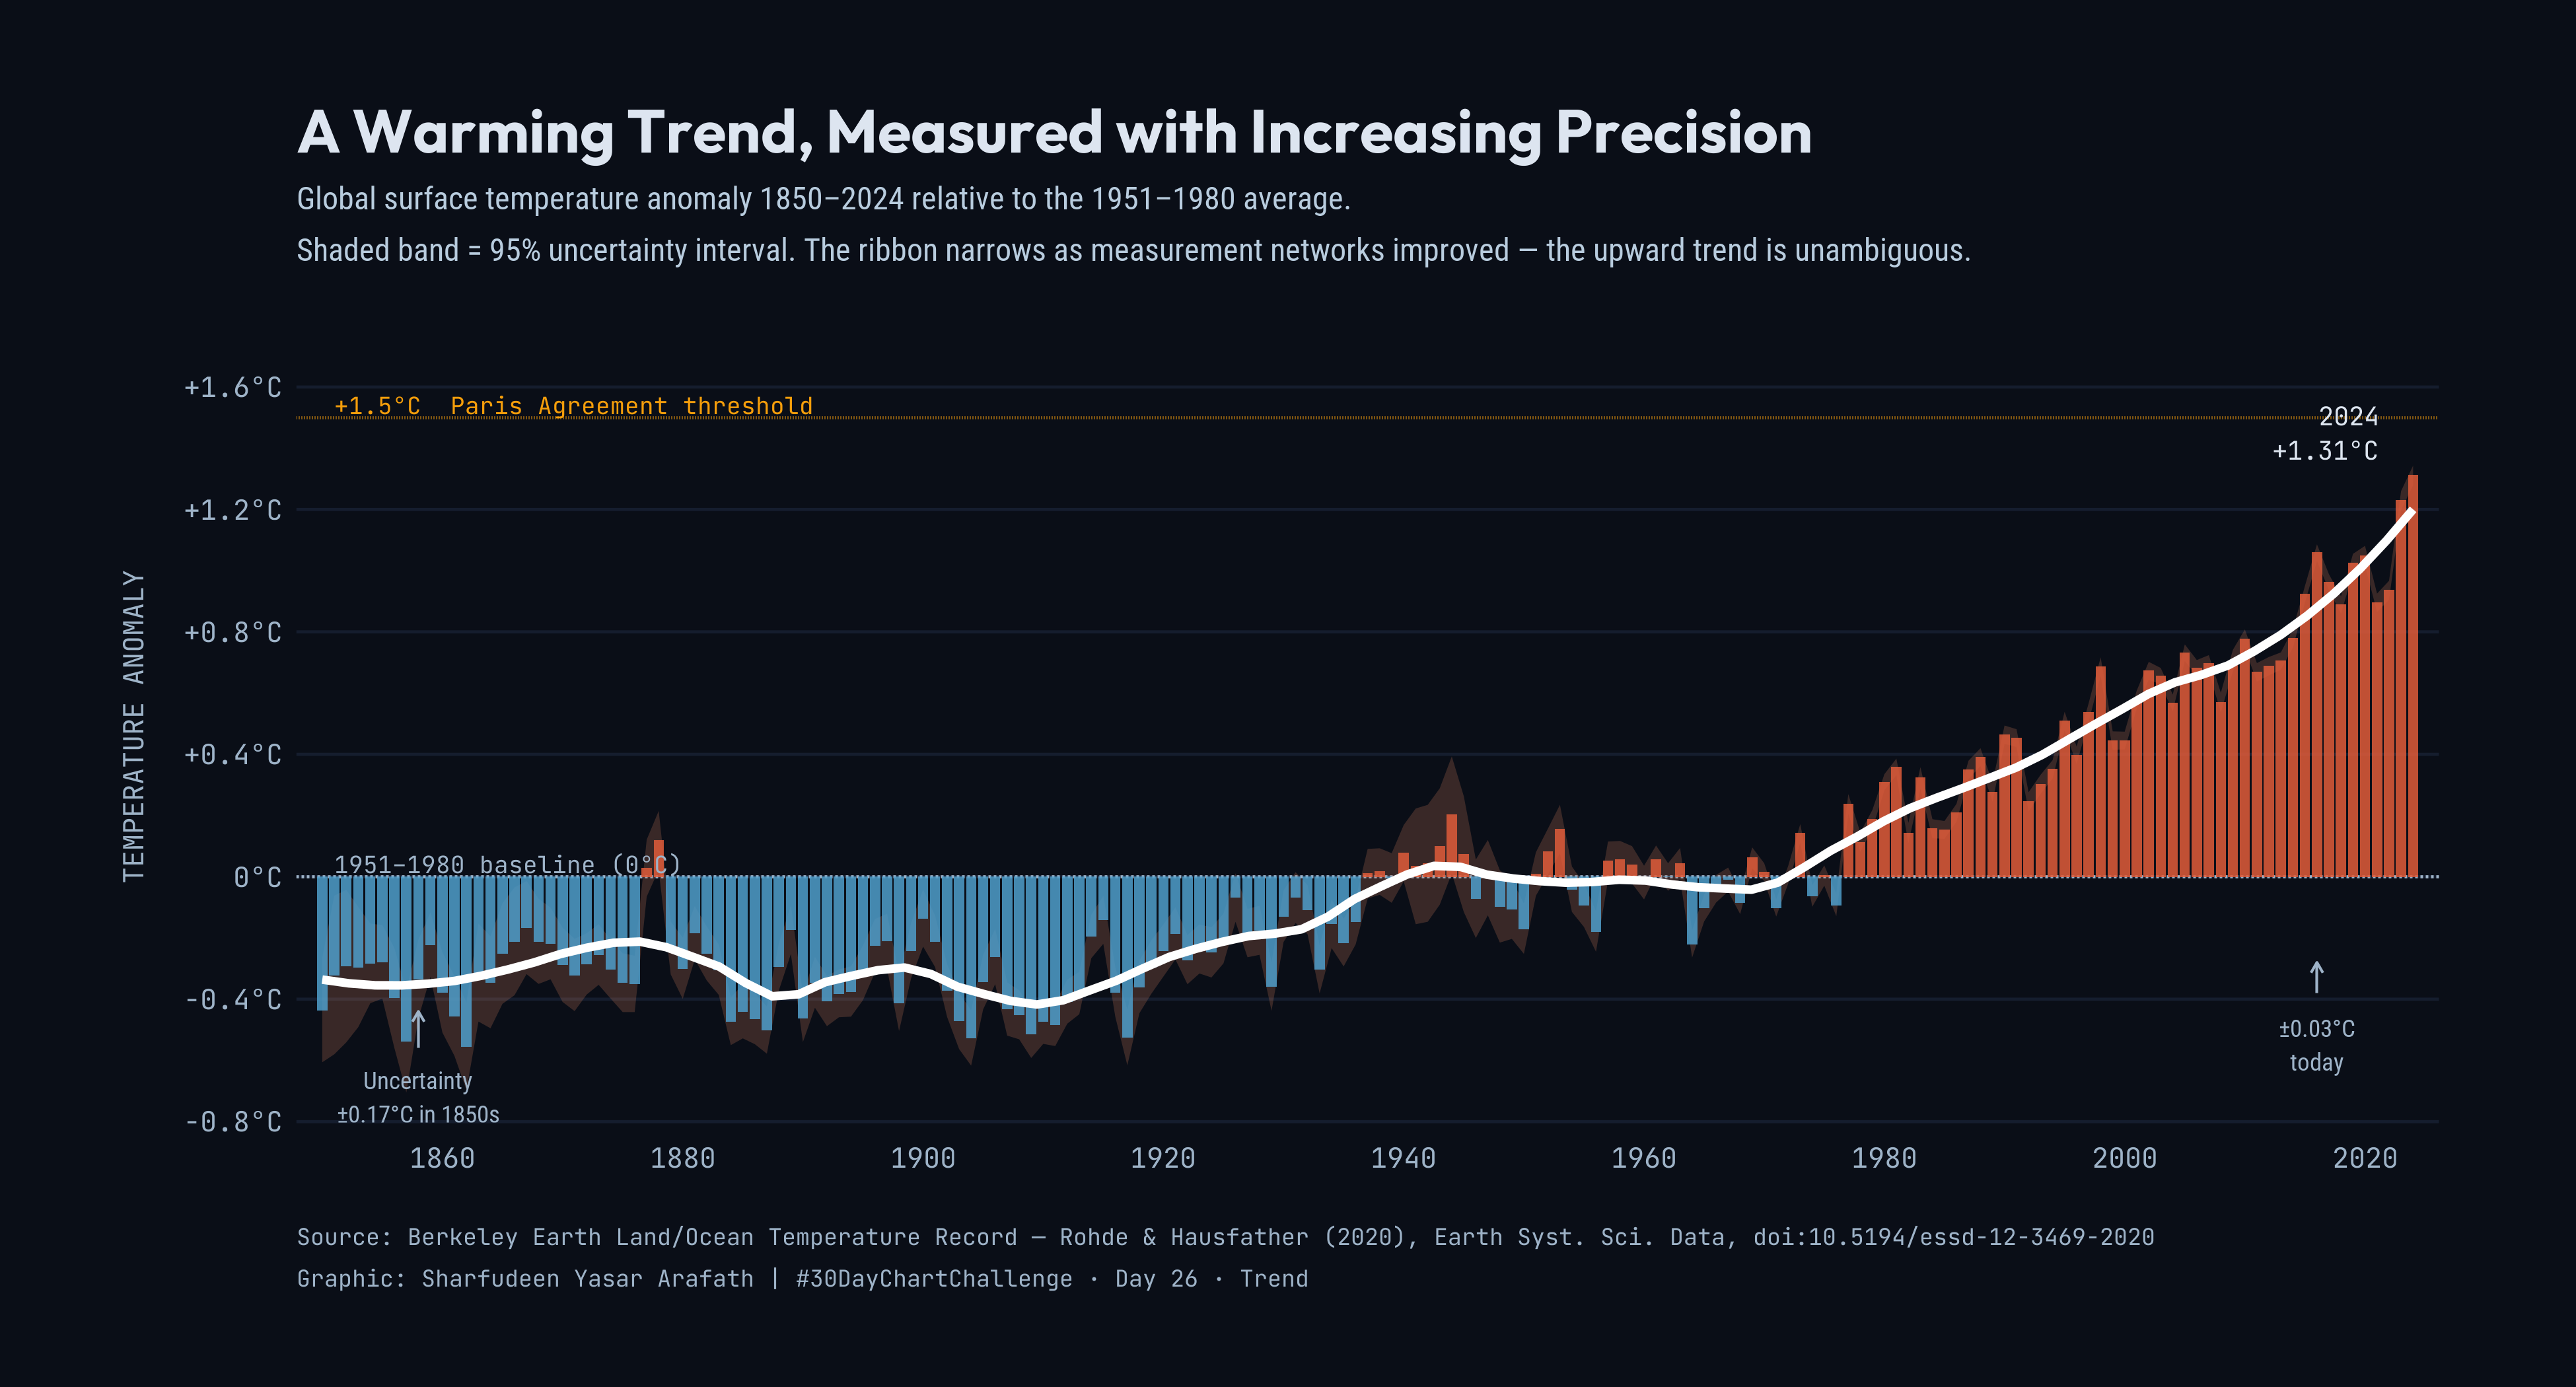

In [3]:
bg_col   <- "#0a0e17"
text_col <- "#dde5f0"
subtext  <- "#9eb3c8"
grid_col <- "#151d2e"

# Diverging: cold blue (negative) → warm red (positive)
col_neg  <- "#4f9dca"
col_pos  <- "#e05c3a"
col_band <- "#c97a5a"   # ribbon colour (warm, since trend is upward)

p <- ggplot(df, aes(x = year)) +

  # 0°C baseline
  geom_hline(yintercept = 0, colour = subtext, linewidth = 0.4, linetype = "dashed") +

  # Paris Agreement +1.5°C threshold
  geom_hline(yintercept = 1.5, colour = "#f59e0b", linewidth = 0.4, linetype = "dotted") +

  # 95% uncertainty ribbon
  geom_ribbon(aes(ymin = lower, ymax = upper),
              fill = col_band, alpha = 0.25) +

  # Annual anomaly bars coloured by sign
  geom_col(aes(y = anomaly,
               fill = ifelse(anomaly >= 0, "above", "below")),
           width = 0.8, alpha = 0.85) +
  scale_fill_manual(values = c("above" = col_pos, "below" = col_neg),
                    guide = "none") +

  # 10-year LOESS trend line
  geom_smooth(aes(y = anomaly), method = "loess", span = 0.18,
              colour = "white", linewidth = 1.1, se = FALSE) +

  # Baseline label
  annotate("text", x = 1851, y = 0.04, hjust = 0, size = 3,
           label = "1951–1980 baseline (0°C)",
           colour = subtext, family = "jetbrains") +

  # Paris threshold label
  annotate("text", x = 1851, y = 1.54, hjust = 0, size = 3,
           label = "+1.5°C  Paris Agreement threshold",
           colour = "#f59e0b", family = "jetbrains") +

  # 2024 value label
  annotate("text", x = 2021, y = 1.45, hjust = 1, size = 3.3,
           label = "2024\n+1.31°C",
           colour = text_col, family = "jetbrains", lineheight = 1.1) +

  # Uncertainty callout — early period
  annotate("text", x = 1858, y = -0.72, hjust = 0.5, size = 3.1,
           label = "Uncertainty\n±0.17°C in 1850s",
           colour = subtext, family = "roboto_condensed", lineheight = 1.15) +
  annotate("segment", x = 1858, xend = 1858, y = -0.56, yend = -0.44,
           colour = subtext, linewidth = 0.35,
           arrow = arrow(length = unit(0.06, "inches"), type = "open")) +

  # Uncertainty callout — recent period
  annotate("text", x = 2016, y = -0.55, hjust = 0.5, size = 3.1,
           label = "±0.03°C\ntoday",
           colour = subtext, family = "roboto_condensed", lineheight = 1.15) +
  annotate("segment", x = 2016, xend = 2016, y = -0.38, yend = -0.28,
           colour = subtext, linewidth = 0.35,
           arrow = arrow(length = unit(0.06, "inches"), type = "open")) +

  scale_x_continuous(
    breaks = seq(1860, 2020, 20),
    expand = expansion(mult = c(0.01, 0.01))
  ) +
  scale_y_continuous(
    breaks = seq(-0.8, 1.6, 0.4),
    labels = function(x) paste0(ifelse(x > 0, "+", ""), x, "°C"),
    expand = expansion(mult = c(0.05, 0.12))
  ) +

  labs(
    title    = "A Warming Trend, Measured with Increasing Precision",
    subtitle = paste0(
      "Global surface temperature anomaly 1850–2024 relative to the 1951–1980 average.\n",
      "Shaded band = 95% uncertainty interval. The ribbon narrows as measurement networks improved — ",
      "the upward trend is unambiguous."
    ),
    x       = NULL,
    y       = "TEMPERATURE ANOMALY",
    caption = paste0(
      "Source: Berkeley Earth Land/Ocean Temperature Record — Rohde & Hausfather (2020), ",
      "Earth Syst. Sci. Data, doi:10.5194/essd-12-3469-2020\n",
      "Graphic: Sharfudeen Yasar Arafath | #30DayChartChallenge · Day 26 · Trend"
    )
  ) +

  theme_minimal(base_family = "outfit", base_size = 13) +
  theme(
    plot.background    = element_rect(fill = bg_col, colour = NA),
    panel.background   = element_rect(fill = bg_col, colour = NA),
    panel.grid.major.x = element_blank(),
    panel.grid.major.y = element_line(colour = grid_col, linewidth = 0.4),
    panel.grid.minor   = element_blank(),

    plot.title    = element_text(family = "outfit", face = "bold", size = 22,
                                 colour = text_col, margin = margin(b = 8)),
    plot.subtitle = element_text(family = "roboto_condensed", size = 11.5,
                                 colour = "#b8ccde", lineheight = 1.35, margin = margin(b = 20)),
    plot.caption  = element_text(family = "jetbrains", size = 8.5, colour = subtext,
                                 hjust = 0, lineheight = 1.5, margin = margin(t = 20)),

    axis.text   = element_text(family = "jetbrains", size = 10, colour = subtext),
    axis.title.y = element_text(family = "jetbrains", size = 10, colour = subtext,
                                margin = margin(r = 12)),

    plot.margin = margin(40, 50, 35, 45)
  )

p

In [4]:
ggsave("../../chart/day_26_trend.png", plot = p,
       width = 13, height = 7, dpi = 300, bg = bg_col)
cat("\u2705 Day 26 Trend chart saved\n")

`geom_smooth()` using formula = 'y ~ x'


✅ Day 26 Trend chart saved
